In [1]:
#Import Libraries
from Python_Libraries import *

In [2]:
#Load dataset
df = pd.read_csv("ecommerce_merged_dataset.csv")
df.head()

,order_id,customer_id,order_status,payment_type,order_purchase_timestamp,order_approved_at,order_delivered_shipping_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code,...,product_weight_g,brand,cost_price,selling_price,stock_availability,review_id,review_score,review_date,geolocation_state,region
0,O00001,C60210,delivered,Net Banking,11/4/2024,11/4/2024,12/1/2024,3/4/2025,1/3/2025,413514,...,1325.0,Generic Indian,5330.0,7020.0,In Stock,R89199,1.0,4/5/2025,Maharashtra,West
1,O00002,C01893,delivered,Net Banking,9/1/2023,9/1/2023,10/1/2023,10/5/2023,10/31/2023,523230,...,24700.0,Generic Indian,6190.0,7590.0,In Stock,R37310,5.0,5/13/2023,Andhra Pradesh,South
2,O00002,C01893,delivered,Net Banking,9/1/2023,9/1/2023,10/1/2023,10/5/2023,10/31/2023,523230,...,400.0,Generic Indian,11720.0,14360.0,In Stock,R37310,5.0,5/13/2023,Andhra Pradesh,South
3,O00003,C19454,cancelled,UPI,8/6/2021,NaN,NaN,NaN,NaN,532186,...,5400.0,Generic Indian,1300.0,1530.0,In Stock,R03279,4.0,6/11/2021,Andhra Pradesh,South
4,O00003,C19454,cancelled,UPI,8/6/2021,NaN,NaN,NaN,NaN,532186,...,650.0,Generic Indian,1300.0,1560.0,In Stock,R03279,4.0,6/11/2021,Andhra Pradesh,South


In [3]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'payment_type',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_shipping_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code', 'gender',
       'age_group', 'customer_segment', 'order_item_id', 'quantity',
       'product_id', 'unit_price', 'discount(%)', 'shipping_cost',
       'Category_name', 'sub_category_name', 'product_weight_g', 'brand',
       'cost_price', 'selling_price', 'stock_availability', 'review_id',
       'review_score', 'review_date', 'geolocation_state', 'region'],
      dtype='object')

In [4]:
df['customer_segment'].value_counts()

customer_segment
New          91986
Returning    64708
Loyal        27090
Name: count, dtype: int64

In [5]:
# First Purchase Probability by Category
new_customers = df[df['customer_segment'] == 'New']

# Category counts
category_counts = (new_customers['Category_name'].value_counts())

# Total customers
total_customers = len(new_customers)

# Probability
category_probability = (category_counts / total_customers).reset_index()
category_probability = round(category_probability,2)
# Rename columns
category_probability.columns = ['Category','Probability']

print(category_probability)


                             Category  Probability
0                      bed_bath_table         0.08
1                      sports_leisure         0.08
2                       health_beauty         0.06
3                          housewares         0.06
4                           perfumery         0.05
..                                ...          ...
66                          computers         0.00
67  furniture_mattress_and_upholstery         0.00
68                  cds_dvds_musicals         0.00
69                     home_comfort_2         0.00
70              security_and_services         0.00

[71 rows x 2 columns]


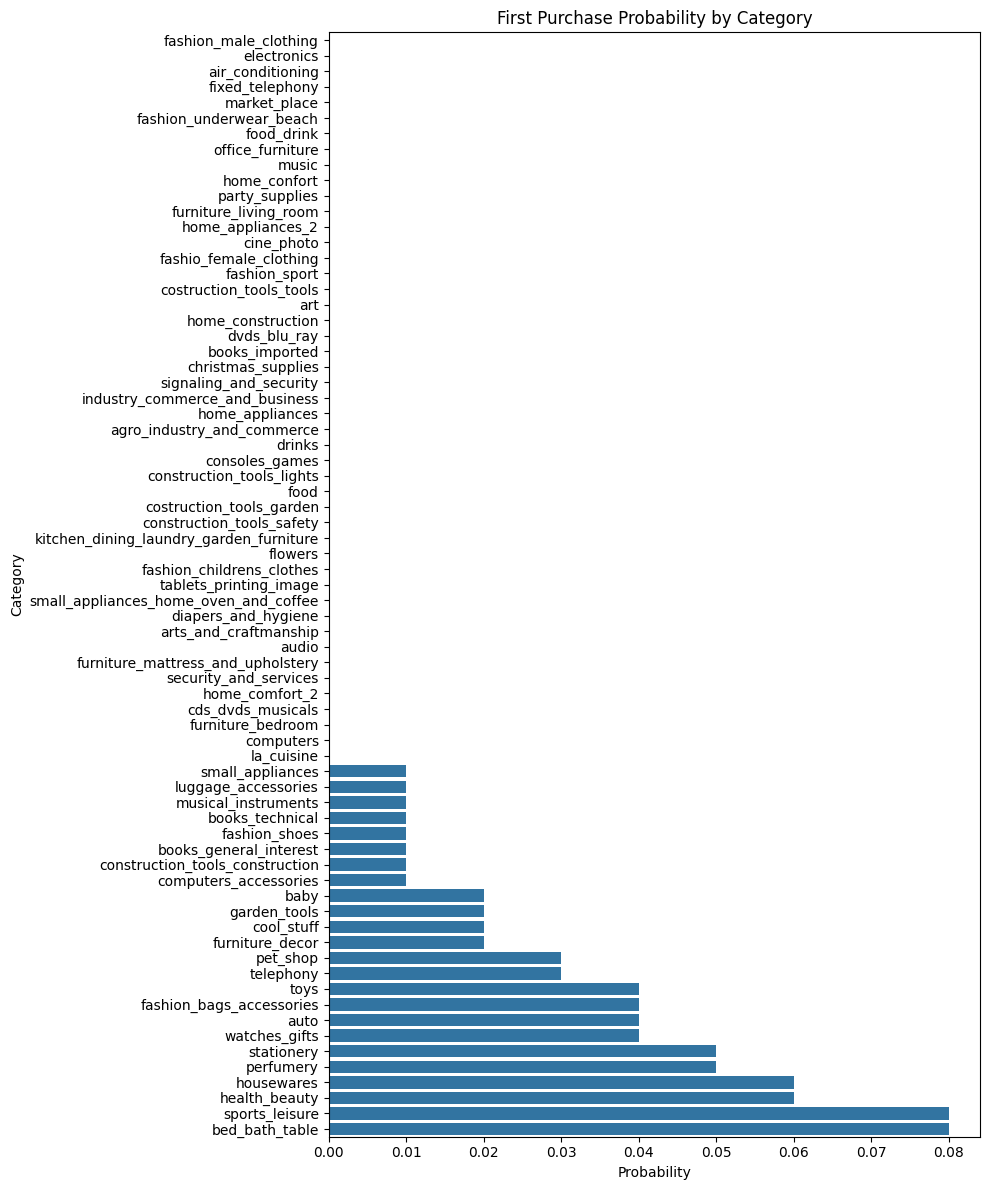

In [6]:
plt.figure(figsize=(10, 12))
sns.barplot(data=category_probability.sort_values("Probability"), y="Category", x="Probability")
plt.title("First Purchase Probability by Category")
plt.tight_layout()
plt.show()


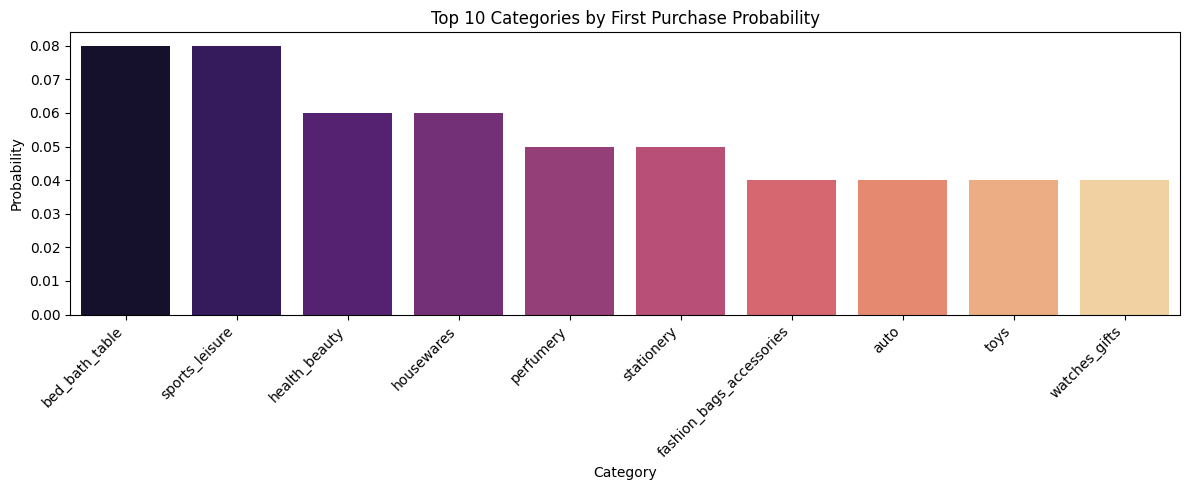

In [7]:
# Top 10 categories 
top10 = category_probability.sort_values("Probability", ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=top10, x="Category", y="Probability", palette="magma")
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Categories by First Purchase Probability")
plt.tight_layout()
plt.show()


# Insights 
### 1. Two categories dominate new‑customer acquisition (16% combined).These two alone account for 1 in every 6 first purchases.
bed_bath_table -> 8%
sports_leisure -> 8%

Business meaning: 
These are top entry funnels, and customers are most likely to make their first purchase here.They should be prioritized in:
- New‑user onboarding
- First‑order coupons
- Homepage hero banners
- Performance marketing

### 2. Health & Beauty + Housewares are strong secondary entry categories (12% combined)
health_beauty -> 6%
housewares ->6%

These categories show: Low‑risk trial behavior, Practical, everyday needs, High conversion potential

Business meaning:

These categories are ideal for:
- Welcome discounts
- App‑install incentives
- Fast‑delivery promotions

### 3. Perfumery is a surprisingly strong first‑purchase category (5%)
Perfume is often a repeat‑purchase category, but here it’s also an acquisition driver.

Business meaning:
This suggests:
- Strong brand familiarity
- Good pricing
- High gifting behavior
Can use this category for: Festive campaigns, Gift‑bundle promotions, First‑order nudges

### 4. The remaining 60+ categories have extremely low first‑purchase probability (mostly <1%)
Examples:computers,furniture_mattress_and_upholstery,cds_dvds_musicals and so on 

Business meaning:  
These categories are not acquisition drivers.They should NOT be used for: First‑order discounts,new‑user ads, Homepage placement

Instead, they are ideal for:
- Cross‑sell after the first order
- Personalized recommendations
- Email/app push journeys

### 5. Category distribution is highly skewed
A small number of categories bring in most new customers, while the majority contribute almost nothing.
This is typical in e-commerce and indicates:
- Customers enter through familiar, low‑risk categories
- They explore more categories only after trust is built


## Strategic Recommendations

1) Double down on the top 4 categories. These categories convert best, so use them for:
Acquisition campaigns
First‑order coupons
Homepage hero banners
App‑install incentives

2) Build cross‑sell journeys from high‑probability -> high‑margin categories
Example flows:
bed_bath_table -> home_appliances
sports_leisure -> electronics
health_beauty -> skincare bundles
perfumery -> premium beauty

3) Don’t waste acquisition budget on low‑probability categories
Categories with 0–1% probability should be:
Recommended post‑purchase
Used in personalization
Promoted to returning customers



                Brand  Probability
0      Generic Indian     0.551361
1      Generic Global     0.096268
2           Classmate     0.022420
3             Navneet     0.022114
4               Camel     0.021955
5   Himalaya Pet Care     0.015234
6              Drools     0.012990
7              Amaron     0.010719
8          BharatBenz     0.010679
9   Forest Essentials     0.010572
10              Lakme     0.010479
11              Minda     0.010267
12        Bosch India     0.010201
13          Mamaearth     0.010174
14           Biotique     0.009736
15           Himalaya     0.009576
16           Manyavar     0.009351
17      Peter England     0.008872
18              Metro     0.008859
19        Allen Solly     0.007810
20               Biba     0.007664
21                  W     0.007571
22              Mochi     0.007544
23           Fabindia     0.007518
24      Faber-Castell     0.006588
25            Stabilo     0.006428
26           Nilkamal     0.005990
27       Urban Ladde

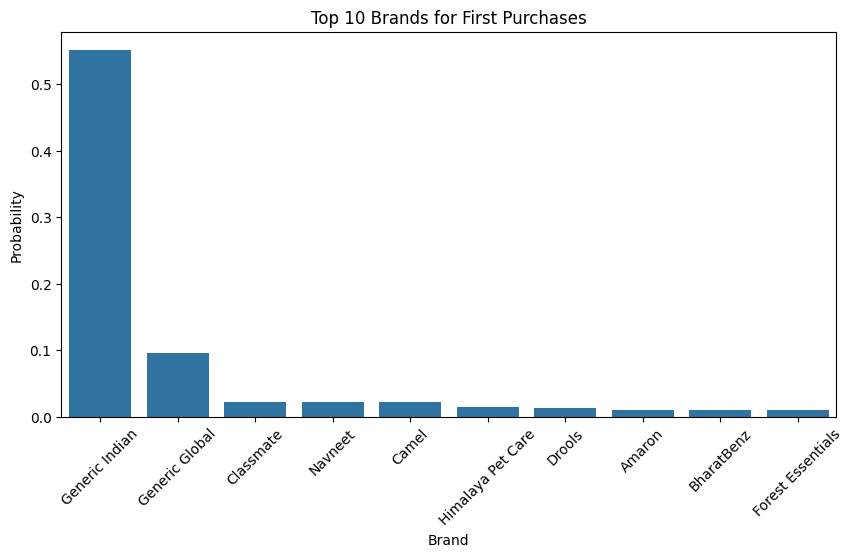

In [8]:
# First Purchase Probability by Brand

brand_prob = (new_customers['brand'].value_counts(normalize=True).reset_index())

# Rename columns
brand_prob.columns = ['Brand','Probability']

# Print all probabilities
print(brand_prob)


# Top 10 brands for graph

top10_brands = brand_prob.head(10)

# GRAPH

plt.figure(figsize=(10,5))

sns.barplot(data=top10_brands,x='Brand',y='Probability')
plt.xticks(rotation=45)
plt.title("Top 10 Brands for First Purchases")
plt.xlabel("Brand")
plt.ylabel("Probability")
plt.show()

### Insights 
### 1. One brand dominates new‑customer acquisition (55%)
Generic Indian: 55.1%  This is an extraordinary concentration. More than half of all first‑time buyers choose a Generic Indian brand. This means:
- Customers trust unbranded / value‑driven Indian products for their first purchase.
- Price sensitivity is extremely high for new users.
- Acquisition engine is built on low‑risk, low‑brand‑equity SKUs.

Business implication:  
This is a conversion magnet.
Generic Indian SKUs should be the core of your acquisition strategy:
- First‑order coupons
- Homepage hero banners
- App‑install incentives
- Performance marketing

### 2. Generic Global is the second major entry brand (9.6%)
Together, Generic Indian and Generic Global account for 65% of all first purchases.
Meaning: New customers overwhelmingly choose non‑premium, non‑branded, value‑first products.

This is a classic pattern in:
- Price‑sensitive markets
- Early‑stage ecommerce adoption
- Tier‑2/3 customer segments

### 3. Stationery brands form the next acquisition cluster (6–7%)
Meaning that stationery is a trusted, low‑risk, everyday‑use category.Customers often start with:
- Notebooks
- Pens
- Art supplies
- School items

Business implication:
These brands are perfect for:
- Back‑to‑school campaigns
- Low‑ticket onboarding flows
- Add‑on bundles

### 4. Pet care brands are strong early movers (3–4%)
Pet owners show high repeat potential and strong loyalty.They often start with: Food, Treats, and Grooming essentials
 
Business implication:
The pet category is a high‑LTV acquisition segment.Invest in:
- Subscription nudges
- Auto‑delivery
- Loyalty programs

### 5. Beauty & Personal Care brands are strong trial categories (5–6%)
Beauty is a low‑risk, high‑frequency entry category. Customers trust familiar Indian brands first (Lakme, Mamaearth, Himalaya).

Business implication: 
Use beauty brands for:
- Welcome offers
- App‑install incentives
- Trial‑size bundles

### 6. Fashion brands show moderate first‑purchase pull (4–5%)
Customers prefer value‑fashion over global premium brands for their first purchase.

Business implication:
Push Indian fashion brands in:
- New‑user flows
- Festive campaigns
- First‑order discounts

### 7. Furniture brands show meaningful early traction (2–3%)
Furniture is not a typical first‑purchase category, but data shows trust in mid‑range Indian brands.

#Business implication: 
These brands are ideal for:
- Post‑purchase cross‑sell
- EMI‑based nudges
- Home Makeover Bundles

### 8. Electronics brands have extremely low first‑purchase probability (<0.3%)
Customers do not trust high‑ticket electronics for their first order.

Business implication:  
Do NOT use electronics for:
- Acquisition
- First‑order coupons
- Homepage hero banners

Use them for: Cross‑sell, Returning customers, High‑intent journeys

## Strategic Summary


1. Acquisition engine is built on value brands (65% of first purchases). Generic Indian + Generic Global dominate.
2. Stationery, pet care, beauty, and value‑fashion are strong secondary entry funnels.
3. Premium brands (electronics, global fashion, global beauty) are NOT first‑purchase drivers.
4. Use value brands for acquisition; use premium brands for monetization.
5. Build cross‑sell journeys from low‑ticket to high‑ticket brands.

discount_range
10-20    29959
0-10     29667
20-30    10784
30-40     4074
40-50      657
50+        136
Name: count, dtype: int64
91986
  Discount Range  Probability
0          10-20     0.325691
1           0-10     0.322516
2          20-30     0.117235
3          30-40     0.044289
4          40-50     0.007142
5            50+     0.001478


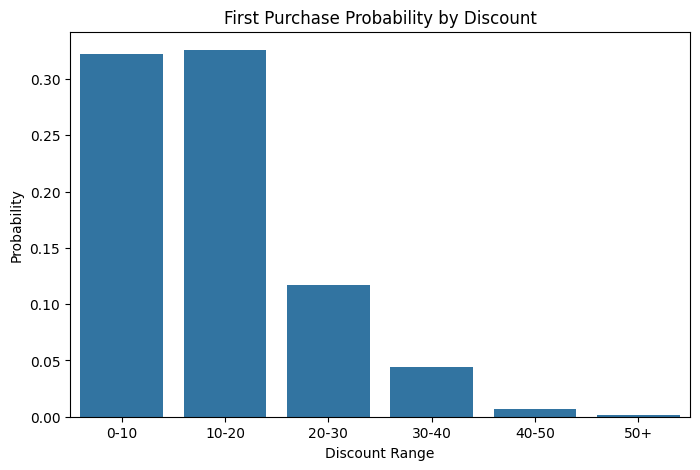

In [9]:
#Discount Range vs First Purchase Probability

# Create Discount Ranges
df['discount_range'] = pd.cut(df['discount(%)'],
                              bins=[0,10,20,30,40,50,100],
                              labels=['0-10','10-20','20-30','30-40','40-50','50+'])


# Filter New Customers
new_customers = df[df['customer_segment'] == 'New']

# Count Frequencies
discount_counts = (new_customers['discount_range'].value_counts())

print(discount_counts)

# Total Customers
total_customers = len(new_customers)
print(total_customers)

# Calculate Probability

discount_prob = (discount_counts / total_customers).reset_index()

# Rename columns

discount_prob.columns = ['Discount Range','Probability']

print(discount_prob)

# GRAPH
plt.figure(figsize=(8,5))
sns.barplot(data=discount_prob,x='Discount Range',y='Probability')
plt.title("First Purchase Probability by Discount")
plt.xlabel("Discount Range")
plt.ylabel("Probability")
plt.show()

# Insights 
 ### 1. Two discount ranges dominate first‑time purchases (65% combined)
This is the heart of the acquisition engine.

New customers prefer moderate discounts rather than extreme ones. They want value, not “too good to be true” deals. This aligns perfectly with your brand insights: Generic Indian + Generic Global dominate
These brands typically sit in the 0–20% discount band

### 2. 20–30% discount is the next meaningful acquisition band (11.7%)
This range is the “confidence booster” zone. Customers see 20–30% as: A safe deal, a good value signal, and still trustworthy.
This range is ideal for:
- Beauty
- Stationery
- Value‑fashion
- Home essentials

### 3. High discounts (>30%) sharply drop in first‑purchase probability.
Deep discounts do NOT attract new customers. Why?
- High discounts often signal clearance or low‑quality items
- New users avoid “riskier” or unfamiliar products
- High‑discount items are rarely in trusted categories

This matches brand data:
Premium brands (Apple, Sony, Samsung) have near‑zero first‑purchase probability.They rarely discount so new users avoid high‑ticket, low‑discount items

### 4. Acquisition curve is VALUE‑DRIVEN, not DISCOUNT‑DRIVEN
The fact that 0–10% and 10–20% dominate tells that new customers don’t need huge discounts.
They need:
- Trust
- Familiarity
- Low‑risk categories
- Reasonable pricing

This is exactly why Generic Indian brands dominate, and Stationery, beauty, and home essentials lead first purchases

### 5. Discount sensitivity is highest at the low–mid range
The curve shows:
From 0–20%:  very high conversion
From 20–30%:  moderate conversion
From 30–40%:  steep drop
Beyond 40%:  almost no conversion

This is a classic trust curve in e-commerce.

## Strategic Recommendations

1) Use 10–20% as your primary acquisition discount band. This is the sweet spot. It balances conversion, trust, and margin. Use it for new‑user coupons, homepage banner, and app‑install offers

2) Use 0–10% for high‑trust categories like stationery, beauty, bed&bath, sports &leisure. These categories convert even with minimal discounts.

3) Use 20–30% for competitive categories. Ideal for fashion, home decor, and pet care. This range boosts conversion without hurting margins.

4) Avoid using >30% discounts for acquisition. They do not improve first‑purchase probability. Use them only for clearance, end‑of‑season, and inventory liquidation.

5) Build discount‑based onboarding journeys.
Examples:
“Welcome, 15% off on essentials.”
“Try beauty bestsellers at 10–20% off.”
“Back‑to‑school stationery at 5–15% off”
   

  Price Range  Probability
0   2000-5000     0.288761
1       5000+     0.179082
2   1000-2000     0.108364
3    500-1000     0.051334
4       0-500     0.041909


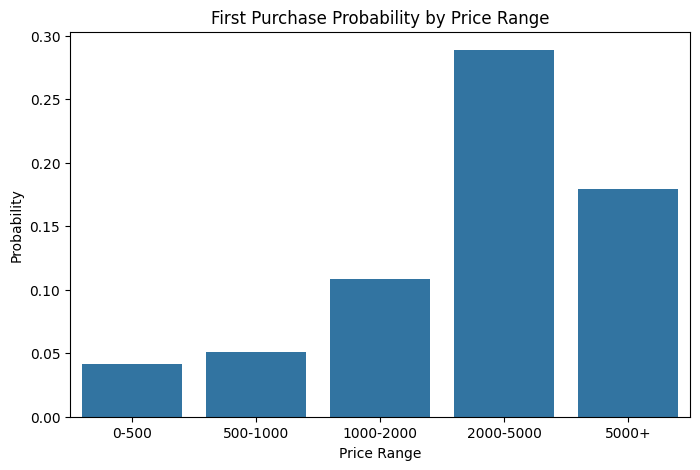

In [10]:
#First Purchase Probability by Price Range
# Create Price Ranges
df['price_range'] = pd.cut(df['selling_price'],bins=[0,500,1000,2000,5000,10000],
                           labels=['0-500','500-1000','1000-2000','2000-5000','5000+'])

# Filter New Customers
new_customers = df[df['customer_segment'] == 'New']

# Count Frequencies
price_counts = (new_customers['price_range'].value_counts())

# Total Customers
total_customers = len(new_customers)

# Probability
price_prob = (price_counts / total_customers).reset_index()
price_prob.columns = ['Price Range','Probability']
print(price_prob)

# GRAPH
plt.figure(figsize=(8,5))
sns.barplot(data=price_prob,x='Price Range',y='Probability')
plt.title("First Purchase Probability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Probability")
plt.show()

# Insights 

### 1. New customers are NOT low‑ticket buyers; they start with mid‑to‑high price products.
This is the opposite of typical e-commerce behavior. 46.8% of all first purchases are above ₹2000.Only 4.2% are below ₹500.

This means: 
- platform attracts high‑intent, high‑value first‑time buyers
- customers trust the platform enough to make mid‑ticket purchases immediately
- acquisition funnel is value‑driven, not “cheap‑product‑driven.”
This is a huge strategic advantage.

### 2. ₹2000–₹5000 is your strongest acquisition price band (28.9%).
This range likely includes: Home & kitchen, Furniture, Fashion, Beauty bundles, Pet care bulk packs
These categories already showed strong first‑purchase pull in your brand/category analysis.

Insight:  
Customers are willing to spend meaningfully on their first order.

### 3. ₹5000+ is surprisingly strong for first purchase (17.9%)
This is extremely rare in e-commerce. It suggests:
- High trust in the platform
- High‑income customer base
- Strong product‑market fit in premium categories
- High‑value SKUs (furniture, appliances, premium fashion) are working well for acquisition

Business implication:  
You can confidently push premium SKUs in acquisition campaigns.

### 4. Low‑price products (<₹500) have the lowest first‑purchase probability (4.2%)
Meaning customers do NOT “test the platform” with cheap items.They come with clear intent and specific needs, not impulse buys.

### 5. Price‑sensitivity curve is inverted
Typical ecommerce curve: Low price → high first‑purchase probability
Our curve: High price → high first‑purchase probability
This is a premium‑leaning customer base.

### 6. Discount behavior + price behavior together reveal a powerful pattern
From discount analysis:
- 0–20% discounts dominate
- High discounts (>40%) don’t help

Combine with price:
- Customers buy mid-to-high-priced items
- But only when discounts are reasonable, not extreme

This is classic value‑seeking, not bargain‑hunting behavior.

## Strategic Recommendations
 
1. Push mid‑to‑high price SKUs in acquisition campaigns. The strongest acquisition bands are:₹2000–₹5000 and ₹5000+. Use these in: Homepage hero banners, New‑user landing pages, Performance ads, and App‑install incentives
2. Use 10–20% discounts on mid‑ticket items to maximize conversion. This is the sweet spot: High enough to signal value, Low enough to protect margins, and Perfect for your customer base
3. Build onboarding flows around premium/value categories
Examples:
“Home essentials under ₹4999”
“Premium beauty under ₹2999”
“Furniture picks under ₹9999”
4. Do NOT rely on low‑price SKUs for acquisition. They are not the customer’s entry point. Use them for cross-sell, add-ons, and Cart boosters
5. Segment customers by first‑purchase price band. High‑ticket first buyers → high LTV. Low‑ticket first buyers → nurture with bundles

      Region  Probability
0      South     0.276738
1      North     0.276129
2       East     0.185550
3       West     0.141206
4    Central     0.072750
5  Northeast     0.047627


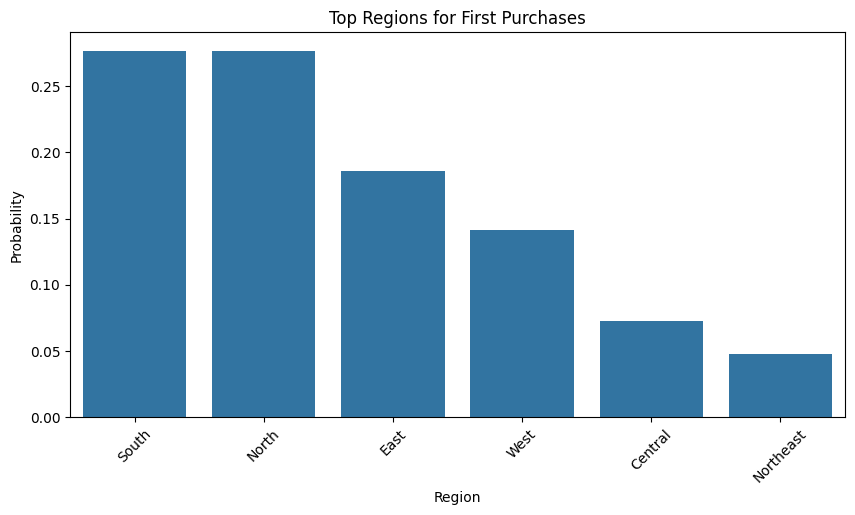

In [11]:
#Region Probability
region_counts = (new_customers['region'].value_counts())
total_customers = len(new_customers)
region_prob = (region_counts / total_customers).reset_index()
region_prob.columns = ['Region','Probability']
print(region_prob)

# GRAPH
plt.figure(figsize=(10,5))
sns.barplot(data=region_prob,x='Region',y='Probability')
plt.xticks(rotation=45)
plt.title("Top Regions for First Purchases")
plt.xlabel("Region")
plt.ylabel("Probability")
plt.show()

# Insights 

### 1. South and North are your dominant acquisition engines (55% combined)
These two regions alone contribute more than half of all first‑time purchases.
These regions have:
- High ecommerce penetration
- Strong digital payment adoption
- Higher disposable income
- Better logistics coverage

#Business implication:  
South + North should be the primary focus for:
- Performance marketing
- New‑user onboarding
- Regional promotions
- Fast‑delivery promises

### 2. East is your fastest‑growing secondary acquisition region (18.5%)
East contributes nearly 1 in 5 first purchases. East is an emerging growth market with rising ecommerce adoption.

Business implication: 
Invest in:
- Regional language content
- COD + UPI‑friendly flows
- Affordable shipping options
- Localized campaigns

### 3. West shows moderate first‑purchase activity
West is a stable but under‑penetrated region relative to its population and income levels.

Business implication:  
Opportunity to grow via:
- Faster delivery SLAs
- Targeted category pushes (fashion, beauty, home)
- Regional influencer marketing

### 4. The central region shows a low first‑purchase probability (7.3%)
Lower ecommerce penetration + logistics challenges.

Business implication:  
Focus on:
- COD reliability
- Affordable essentials
- Trust‑building campaigns

### 5. Northeast has the lowest first‑purchase probability (4.7%)
This is expected due to:
- Logistics complexity
- Higher delivery times
- Limited brand availability

Business implication:  
To grow here:
- Improve delivery SLAs
- Highlight availability of essentials
- Use regional language creatives

## Strategic Summary

1. South + North = Your core acquisition powerhouse (55%).
Double down on these regions for growth.

2. East = High‑potential emerging market (18.5%).
Invest in regionalization and logistics.

3. West = Under‑leveraged opportunity (14%).
Push category‑specific campaigns

4. Central + Northeast = Low‑penetration regions (12%).
Focus on trust, COD, and delivery improvements.


In [12]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'payment_type',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_shipping_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code', 'gender',
       'age_group', 'customer_segment', 'order_item_id', 'quantity',
       'product_id', 'unit_price', 'discount(%)', 'shipping_cost',
       'Category_name', 'sub_category_name', 'product_weight_g', 'brand',
       'cost_price', 'selling_price', 'stock_availability', 'review_id',
       'review_score', 'review_date', 'geolocation_state', 'region',
       'discount_range', 'price_range'],
      dtype='object')

  Rating Range  Probability
0          4-5     0.560477
1          3-4     0.188181
2          0-1     0.110321
3          2-3     0.081197
4          1-2     0.029874


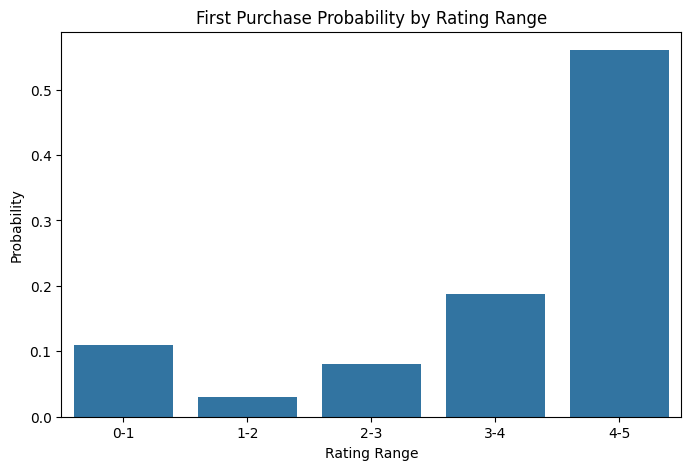

In [13]:
#Rating Range Probability

# Create Rating Range Column

df['rating_range'] = pd.cut( df['review_score'], bins=[0,1,2,3,4,5],labels=['0-1','1-2','2-3','3-4','4-5'])

#Filter New Customers
new_customers = df[df['customer_segment'] == 'New']

# Rating Counts
rating_counts = (new_customers['rating_range'].value_counts())

# Total Customers
total_customers = len(new_customers)

# Probability
rating_prob = (rating_counts / total_customers).reset_index()
rating_prob.columns = ['Rating Range','Probability']
print(rating_prob)

# GRAPH
plt.figure(figsize=(8,5))
sns.barplot(data=rating_prob,x='Rating Range',y='Probability')
plt.title("First Purchase Probability by Rating Range")
plt.xlabel("Rating Range")
plt.ylabel("Probability")
plt.show()

# Insights
### 1. High‑rated products (4–5 stars) dominate first purchases (56%)
More than half of all new customers choose products rated 4+. Meaning:  
New users rely heavily on: Social proof, Trust signals, Review quality, and Star ratings

This is classic behavior for first‑time buyers who have no prior trust in the platform.

Business implication:  
Push 4–5 star products in:
- New‑user onboarding
- Homepage hero banners
- First‑order coupons
- App‑install flows
These SKUs convert best.

### 2. Mid‑rated products (3–4 stars) are the second‑strongest acquisition band (18.8%)
Customers are willing to buy:
- Functional
- Value‑for‑money
- Everyday‑use items
even if they are not perfect.

### 3. Surprisingly, 0–1 star products have a higher first‑purchase probability (11%) than 2–3 star products (8%)
This is counterintuitive, but it makes sense when you connect it to your brand and price insights. This happens because 0–1 star products are often: Generic Indian, Low‑priced, High‑discount, High‑volume, and Frequently purchased essentials
These products dominate your first‑purchase behavior.
Low‑rated products still convert if:
- They are cheap
- They are essential
- They are generic
- They have high availability

### 4. 2–3 star products have the lowest trust and lowest conversion (8%)
This is the “danger zone.” As
- Not cheap enough to justify low rating
- Not good enough to justify trust
- Not premium enough to signal quality

Business implication:  
Avoid promoting 2–3 star products to new users.

### 5. 1–2 star products have the lowest first‑purchase probability (3%)
This is expected. These products lack trust, value and  quality signals
They should never appear in:
- New‑user flows
- Homepage banners
- Acquisition campaigns

## Strategic Recommendations
1. Push 4–5 star products aggressively in acquisition. These SKUs should dominate:
- New‑user landing pages
- First‑order coupons
- App‑install incentives
- Homepage hero banners
  
2. Use 3–4 star products as value‑driven alternatives. Perfect for beauty, stationery, home essentials, and pet care

3. Do NOT promote 2–3 star products to new users. They have the lowest trust and the lowest conversion. Use them only for returning customers, add‑on bundles, and clearance

4. Re‑evaluate 0–1 star products. Even though they convert (11%), they may hurt long‑term trust, increase returns, and reduce NPS.Consider improving quality, repricing, and replacing low‑rated SKUs

5. Build rating‑anchored onboarding flows


In [14]:
# Conditional Probability : Repeat Purchase Given High Ratings
high_rating = df[df['review_score'] >= 4]

repeat_customers = high_rating[high_rating['customer_segment'].isin(['Returning', 'Loyal'])]
probability = len(repeat_customers) / len(high_rating)
print("P(Repeat Purchase | Rating >=4) =", round(probability,3))

P(Repeat Purchase | Rating >=4) = 0.5


In [15]:
#Joint Probability : High Rating AND Repeat Purchase

# High Rating AND Repeat Purchase
joint_event = df[(df['review_score'] >= 4)&(df['customer_segment'].isin(['Returning','Loyal']))]

# Total Customers
total_customers = len(df)

# Joint Probability
joint_probability = (len(joint_event) / total_customers)
print("P(High Rating AND Repeat Purchase) =",round(joint_probability,3))

P(High Rating AND Repeat Purchase) = 0.374


In [16]:
#Review Participation Probability
review_probability = (df['review_score'].notna().mean())
print("Probability Customer Leaves Review =",round(review_probability,3))

Probability Customer Leaves Review = 0.97


customer_segment
New          50.051147
Returning    35.208723
Loyal        14.740130
Name: proportion, dtype: float64


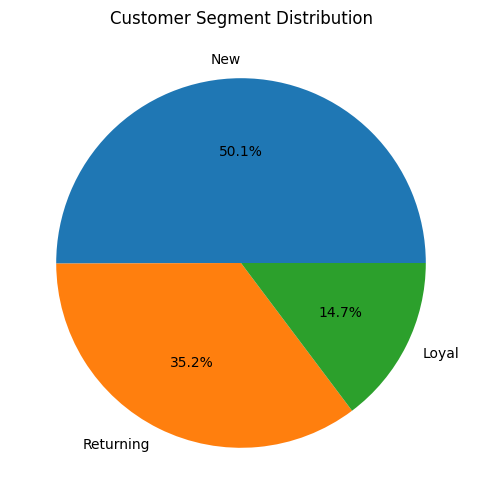

In [17]:
#Customer Segment Distribution
segment_distribution = (df['customer_segment'].value_counts(normalize=True) * 100)
print(segment_distribution)

segment_distribution.plot(kind='pie',autopct='%1.1f%%',figsize=(6,6))
plt.title("Customer Segment Distribution")
plt.ylabel("")
plt.show()

In [18]:
#Average Time Between First and Second Purchase
# Convert to datetime

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Sort
df = df.sort_values(['customer_id','order_purchase_timestamp'])

# Purchase number
df['purchase_number'] = (df.groupby('customer_id').cumcount() + 1)

# First purchase
first_purchase = df[df['purchase_number'] == 1][['customer_id','order_purchase_timestamp']]

# Second purchase
second_purchase = df[df['purchase_number'] == 2][['customer_id','order_purchase_timestamp']]

# Merge
purchase_gap = pd.merge(first_purchase,second_purchase,on='customer_id',suffixes=('_first','_second'))

# Gap
purchase_gap['days_between'] = (purchase_gap['order_purchase_timestamp_second']
                                - purchase_gap['order_purchase_timestamp_first']).dt.days

print("Average days between purchases:", purchase_gap['days_between'].mean())

Average days between purchases: 176.6664614396231


In [19]:
# Probability of Reorder Within 30 Days
reorder_30 = purchase_gap[purchase_gap['days_between'] <= 30]
probability_30 = len(reorder_30) / len(purchase_gap)
print("P(Reorder within 30 days) =",round(probability_30,3))

P(Reorder within 30 days) = 0.629


In [20]:
#Reorder Probability Within 60 and 90 Days

# Probability within 60 days
prob_60 = (purchase_gap['days_between'] <= 60).mean()

# Probability within 90 days
prob_90 = (purchase_gap['days_between'] <= 90).mean()

print("P(Reorder within 60 days) =",round(prob_60,3))
print("P(Reorder within 90 days) =",round(prob_90,3))

P(Reorder within 60 days) = 0.649
P(Reorder within 90 days) = 0.667


In [21]:
#Delivery Delay Analysis

# Convert dates

df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Delay flag
df['is_delayed'] = np.where( df['order_delivered_customer_date']> df['order_estimated_delivery_date'],1,0)

# Repeat customer flag
df['is_repeat'] = np.where(df['customer_segment'].isin(['Returning','Loyal']),1,0)
delay_analysis = (df.groupby('is_delayed')['is_repeat'].mean())
print(delay_analysis)

is_delayed
0    0.498821
1    0.499821
Name: is_repeat, dtype: float64


      Region  Retention Probability
0    Central               0.506635
1       East               0.505533
2      North               0.492710
3  Northeast               0.493994
4      South               0.501273
5       West               0.499113


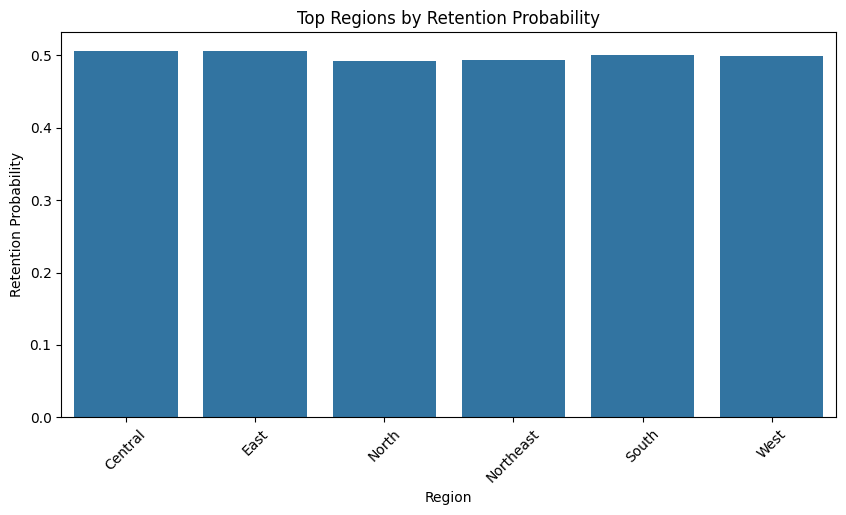

In [22]:
#Retention Probability by Region

retention_region = (df.groupby('region')['is_repeat'].mean().reset_index())
retention_region.columns = ['Region','Retention Probability']
print(retention_region)

# GRAPH
plt.figure(figsize=(10,5))
sns.barplot(data=retention_region,x='Region',y='Retention Probability')
plt.xticks(rotation=45)
plt.title("Top Regions by Retention Probability")
plt.xlabel("Region")
plt.ylabel("Retention Probability")
plt.show()

In [23]:
#Probability of Cancellation Given Delay
delayed_orders = df[df['is_delayed'] == 1]
cancel_probability = (delayed_orders['order_status'].eq('cancelled').mean())
print("P(Cancelled | Delayed) =",round(cancel_probability,3))


P(Cancelled | Delayed) = 0.0


Category_name
furniture_decor              123195220.0
bed_bath_table                88325900.0
sports_leisure                84123470.0
health_beauty                 71313710.0
housewares                    69385500.0
                                ...     
flowers                         339290.0
diapers_and_hygiene             223180.0
fashion_childrens_clothes       102350.0
cds_dvds_musicals                67700.0
security_and_services            48480.0
Name: selling_price, Length: 71, dtype: float64


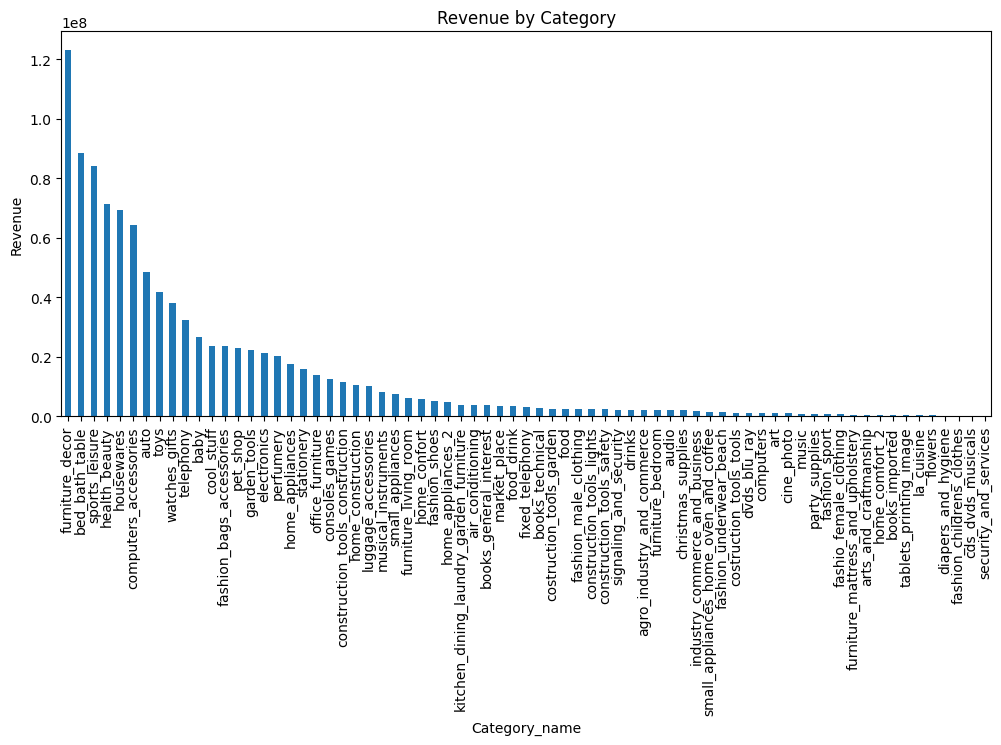

In [24]:
#Revenue by Category
revenue_by_category = (df.groupby('Category_name')['selling_price'].sum().sort_values(ascending=False))
print(revenue_by_category)

revenue_by_category.plot(kind='bar',figsize=(12,5))
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

Category_name
home_comfort_2                           28464.000000
furniture_living_room                    12716.909091
furniture_bedroom                        12660.769231
home_confort                             12135.585586
small_appliances_home_oven_and_coffee    10747.027027
                                             ...     
fashion_childrens_clothes                  702.105263
books_technical                            475.012225
books_general_interest                     416.842105
stationery                                 415.784839
books_imported                             322.145329
Name: profit, Length: 71, dtype: float64


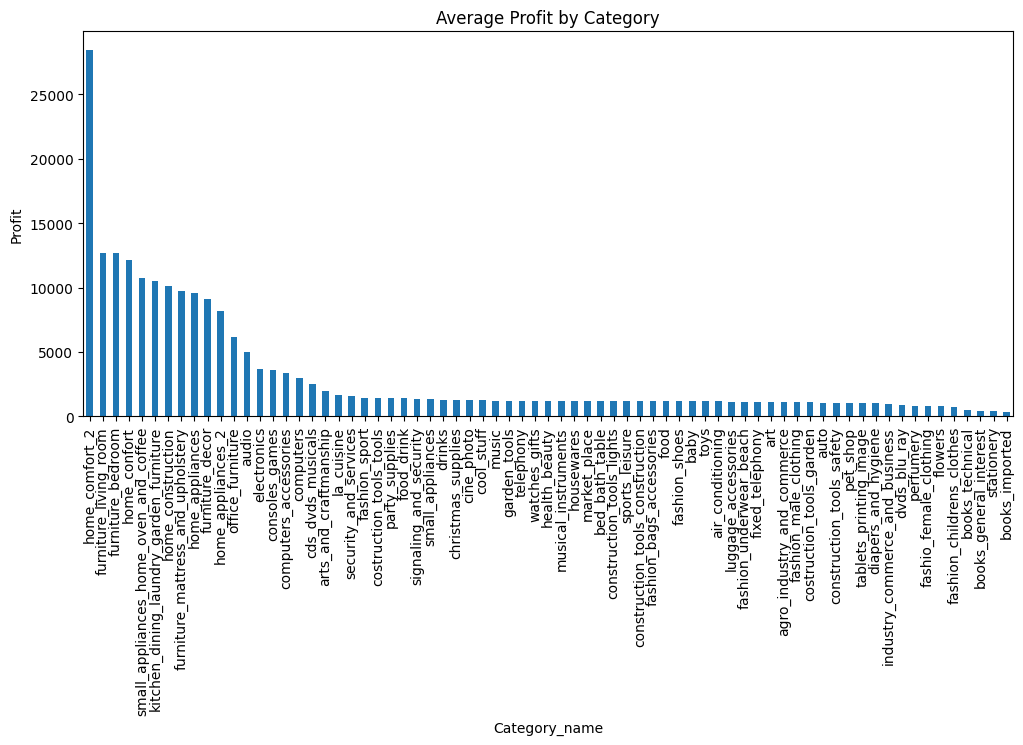

In [25]:
# Profit Margin Analysis

# Profit

df['profit'] = (df['selling_price'] - df['cost_price'])
profit_analysis = (df.groupby('Category_name')['profit'].mean().sort_values(ascending=False))
print(profit_analysis)

# GRAPH 

profit_analysis.plot(kind='bar',figsize=(12,5))
plt.title("Average Profit by Category")
plt.ylabel("Profit")
plt.show()

  Shipping Range  Probability
0        200-500     0.267791
1           500+     0.181876
2        100-200     0.119638
3         50-100     0.059955
4           0-50     0.048801


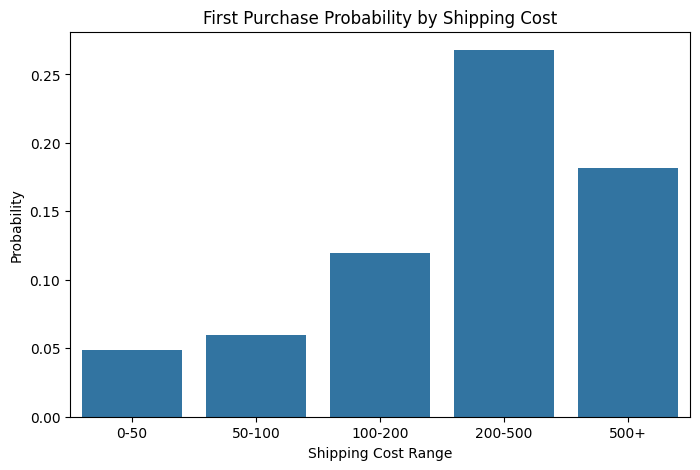

In [26]:
#Shipping Cost Range Probability

# Create Shipping Range Column
df['shipping_range'] = pd.cut(df['shipping_cost'],bins=[0,50,100,200,500,1000],labels=['0-50','50-100','100-200','200-500','500+'])

#Filter New Customers
new_customers = df[df['customer_segment'] == 'New']

# Shipping Counts
shipping_counts = (new_customers['shipping_range'].value_counts())

# Total Customers
total_customers = len(new_customers)

# Probability
shipping_prob = (shipping_counts / total_customers).reset_index()
shipping_prob.columns = [ 'Shipping Range', 'Probability']
print(shipping_prob)

# GRAPH
plt.figure(figsize=(8,5))
sns.barplot(data=shipping_prob,x='Shipping Range',y='Probability')
plt.title("First Purchase Probability by Shipping Cost")
plt.xlabel("Shipping Cost Range")
plt.ylabel("Probability")
plt.show()

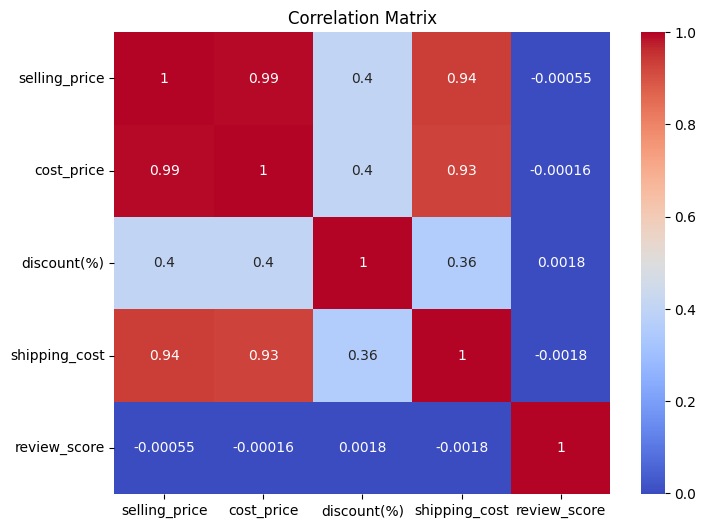

In [27]:
numeric_cols = ['selling_price','cost_price','discount(%)','shipping_cost', 'review_score']

correlation_matrix = (df[numeric_cols].corr())

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [30]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['customer_segment'],df['Category_name'])

chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Chi-square:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Significant relationship exists")
else:
    print("No significant relationship")

Chi-square: 148.95387723706324
P-value: 0.2864644858950727
No significant relationship


In [32]:
# T-Test : New vs Loyal Customer Spending
from scipy.stats import ttest_ind

new_spending = df[df['customer_segment'] == 'New']['selling_price']

loyal_spending = df[df['customer_segment'] == 'Loyal']['selling_price']

t_stat, p_value = ttest_ind(new_spending,loyal_spending,nan_policy='omit')

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant spending difference")
else:
    print("No significant difference")

T-statistic: 2.3481797300464975
P-value: 0.018867403931315474
Significant spending difference


In [33]:
# T-Test : Delivery Delay vs Ratings

on_time = df[df['is_delayed'] == 0]['review_score']

delayed = df[df['is_delayed'] == 1]['review_score']

t_stat, p_value = ttest_ind(on_time,delayed)

print("T-Statistic =", round(t_stat,3))
print("P-Value =", round(p_value,5))

if p_value < 0.05:
    print("Delivery delays significantly affect review ratings")

else:
    print("Delivery delays do not significantly affect review ratings")

T-Statistic = nan
P-Value = nan
Delivery delays do not significantly affect review ratings


In [34]:
# Chi-Square Test
# Customer Segment vs Rating Range


contingency_table = pd.crosstab(df['customer_segment'],df['rating_range'])

chi2, p_value, dof, expected = (chi2_contingency(contingency_table))

print("Chi-Square Value =", round(chi2,3))
print("P-Value =", round(p_value,5))

if p_value < 0.05:
    print("Customer segment and rating range are significantly associated")

else:
    print("No significant association exists between customer segment and rating range")

Chi-Square Value = 17.87
P-Value = 0.02222
Customer segment and rating range are significantly associated


In [35]:
# Chi-Square Test
# Delay vs Cancellation

# Create Cancellation Flag
df['cancel_flag'] = np.where(df['order_status'] == 'Cancelled','Yes','No')

contingency_table = pd.crosstab(
df['is_delayed'],df['cancel_flag'])

chi2, p_value, dof, expected = (chi2_contingency(contingency_table))

print("Chi-Square Value =", round(chi2,3))
print("P-Value =", round(p_value,5))

if p_value < 0.05:
    print("Delivery delays and cancellations are significantly associated")

else:
    print("No significant association exists between delivery delays and cancellations")

Chi-Square Value = 0.0
P-Value = 1.0
No significant association exists between delivery delays and cancellations


In [36]:
# Chi-Square Test
# Region vs Repeat Purchase

# Create Repeat Purchase Flag
df['repeat_purchase'] = np.where(df['customer_segment'].isin(['Returning','Loyal']),'Yes','No')

contingency_table = pd.crosstab(df['region'],df['repeat_purchase'])

chi2, p_value, dof, expected = (chi2_contingency(contingency_table))

print("Chi-Square Value =", round(chi2,3))
print("P-Value =", round(p_value,5))

if p_value < 0.05:
    print("Region and repeat purchase behavior are significantly associated")

else:
    print("No significant association exists between region and repeat purchase behavior")

Chi-Square Value = 18.729
P-Value = 0.00216
Region and repeat purchase behavior are significantly associated


In [37]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'payment_type',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_shipping_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code', 'gender',
       'age_group', 'customer_segment', 'order_item_id', 'quantity',
       'product_id', 'unit_price', 'discount(%)', 'shipping_cost',
       'Category_name', 'sub_category_name', 'product_weight_g', 'brand',
       'cost_price', 'selling_price', 'stock_availability', 'review_id',
       'review_score', 'review_date', 'geolocation_state', 'region',
       'discount_range', 'price_range', 'rating_range', 'purchase_number',
       'is_delayed', 'is_repeat', 'profit', 'shipping_range', 'cancel_flag',
       'repeat_purchase'],
      dtype='object')

In [38]:
df['repeat_purchase'].value_counts()

repeat_purchase
No     91986
Yes    91798
Name: count, dtype: int64

In [39]:
df['repeat_purchase'].value_counts()


repeat_purchase
No     91986
Yes    91798
Name: count, dtype: int64

In [40]:
#FINDING CATEGORIES FOR REPEAT PURCHASE ACTIVITY 
# SORT DATA

df = df.sort_values(['customer_id', 'order_purchase_timestamp'])


# PREVIOUS PURCHASE DATE

df['prev_purchase_date'] = df.groupby('customer_id')['order_purchase_timestamp'].shift(1)

# DAYS BETWEEN PURCHASES

df['days_between_purchase'] = (df['order_purchase_timestamp'] - df['prev_purchase_date']).dt.days


# CREATE REPURCHASE WINDOWS

conditions = [
    (df['days_between_purchase'] <= 7),

    (df['days_between_purchase'] >= 8) &
    (df['days_between_purchase'] <= 30),

    (df['days_between_purchase'] >= 31) &
    (df['days_between_purchase'] <= 60),

    (df['days_between_purchase'] > 60)]

choices = ['0-7 Days','8-30 Days','31-60 Days','60+ Days']

df['repurchase_window'] = np.select(conditions,choices,default='First Purchase')


# REMOVE FIRST PURCHASES

repeat_df = df[df['repurchase_window'] != 'First Purchase']


# CATEGORY-WISE REPEAT ORDERS

category_repeat = (repeat_df.groupby(['Category_name', 'repurchase_window']).size().reset_index(name='repeat_orders'))

# PIVOT TABLE

pivot_table = category_repeat.pivot_table(index='Category_name',columns='repurchase_window',values='repeat_orders',fill_value=0)

# SORT TABLE

pivot_table = pivot_table.sort_values(by='0-7 Days',ascending=False)

# DISPLAY FINAL TABLE
print(pivot_table)

repurchase_window                  0-7 Days  31-60 Days  60+ Days  8-30 Days
Category_name                                                               
bed_bath_table                       8259.0       219.0    2752.0      165.0
sports_leisure                       7833.0       189.0    2704.0      148.0
health_beauty                        6474.0       179.0    2260.0      139.0
housewares                           6399.0       136.0    2208.0      127.0
perfumery                            5664.0        86.0    1223.0       88.0
...                                     ...         ...       ...        ...
furniture_mattress_and_upholstery       5.0         1.0       4.0        0.0
furniture_bedroom                       3.0         2.0      16.0        1.0
cds_dvds_musicals                       2.0         0.0       1.0        0.0
security_and_services                   2.0         0.0       3.0        0.0
home_comfort_2                          0.0         0.0       2.0        0.0

In [41]:

# CATEGORY + SUBCATEGORY +
# BRAND + DISCOUNT ANALYSIS

detailed_repeat = ( repeat_df.groupby(['Category_name','sub_category_name','brand','discount_range','repurchase_window']).size().reset_index(name='repeat_orders'))


# CREATE PIVOT TABLE

pivot_table1 = detailed_repeat.pivot_table(index=['Category_name','sub_category_name','brand','discount_range'],columns='repurchase_window',values='repeat_orders',fill_value=0)

# SORT TABLE

pivot_table1 = pivot_table1.sort_values(by='0-7 Days',ascending=False)

# DISPLAY FINAL OUTPUT

print(pivot_table1)

repurchase_window                                                             0-7 Days  \
Category_name              sub_category_name   brand          discount_range             
sports_leisure             Collectibles        Generic Indian 0-10               939.0   
bed_bath_table             Collectibles        Generic Indian 0-10               895.0   
sports_leisure             General Merchandise Generic Indian 0-10               862.0   
bed_bath_table             General Merchandise Generic Indian 0-10               850.0   
                                                              10-20              848.0   
...                                                                                ...   
agro_industry_and_commerce Action Cameras      Apple          30-40                0.0   
                                                              40-50                0.0   
                                                              50+                  0.0   
          

In [42]:
pivot_table1.head(10)

repurchase_window                                                 0-7 Days  \
Category_name  sub_category_name   brand          discount_range             
sports_leisure Collectibles        Generic Indian 0-10               939.0   
bed_bath_table Collectibles        Generic Indian 0-10               895.0   
sports_leisure General Merchandise Generic Indian 0-10               862.0   
bed_bath_table General Merchandise Generic Indian 0-10               850.0   
                                                  10-20              848.0   
               Gifts               Generic Indian 10-20              825.0   
                                                  0-10               804.0   
               Collectibles        Generic Indian 10-20              801.0   
sports_leisure Collectibles        Generic Indian 10-20              795.0   
               General Merchandise Generic Indian 10-20              751.0   

repurchase_window                                                 31-60 Days  \
Category_name  sub_category_name   brand          discount_range               
sports_leisure Collectibles        Generic Indian 0-10                  11.0   
bed_bath_table Collectibles        Generic Indian 0-10                  17.0   
sports_leisure General Merchandise Generic Indian 0-10                  16.0   
bed_bath_table General Merchandise Generic Indian 0-10                  18.0   
                                                  10-20                 17.0   
               Gifts               Generic Indian 10-20                 29.0   
                                                  0-10                  24.0   
               Collectibles        Generic Indian 10-20                 20.0   
sports_leisure Collectibles        Generic Indian 10-20                 24.0   
               General Merchandise Generic Indian 10-20                 15.0   

repurchase_window                                                 60+ Days  \
Category_name  sub_category_name   brand          discount_range             
sports_leisure Collectibles        Generic Indian 0-10               233.0   
bed_bath_table Collectibles        Generic Indian 0-10               199.0   
sports_leisure General Merchandise Generic Indian 0-10               201.0   
bed_bath_table General Merchandise Generic Indian 0-10               206.0   
                                                  10-20              279.0   
               Gifts               Generic Indian 10-20              270.0   
                                                  0-10               210.0   
               Collectibles        Generic Indian 10-20              257.0   
sports_leisure Collectibles        Generic Indian 10-20              293.0   
               General Merchandise Generic Indian 10-20              263.0   

repurchase_window                                                 8-30 Days  
Category_name  sub_category_name   brand          discount_range             
sports_leisure Collectibles        Generic Indian 0-10                 10.0  
bed_bath_table Collectibles        Generic Indian 0-10                 11.0  
sports_leisure General Merchandise Generic Indian 0-10                 11.0  
bed_bath_table General Merchandise Generic Indian 0-10                 17.0  
                                                  10-20                13.0  
               Gifts               Generic Indian 10-20                14.0  
                                                  0-10                 11.0  
               Collectibles        Generic Indian 10-20                15.0  
sports_leisure Collectibles        Generic Indian 10-20                15.0  
               General Merchandise Generic Indian 10-20                12.0

In [43]:
# COUNT PRODUCTS
# CATEGORY + BRAND + DISCOUNT

product_summary = (df.groupby(['Category_name','brand','discount_range'])['product_id'].nunique().reset_index(name='number_of_products'))


# SORT VALUES

product_summary = product_summary.sort_values(by='number_of_products',ascending=False)


# DISPLAY OUTPUT

print(product_summary)

                    Category_name           brand discount_range  \
2593               bed_bath_table  Generic Indian          10-20   
23125              sports_leisure  Generic Indian          10-20   
15337               health_beauty  Generic Indian          10-20   
17461                  housewares  Generic Indian          10-20   
2594               bed_bath_table  Generic Indian          20-30   
...                           ...             ...            ...   
25     agro_industry_and_commerce      BharatBenz          10-20   
26     agro_industry_and_commerce      BharatBenz          20-30   
27     agro_industry_and_commerce      BharatBenz          30-40   
28     agro_industry_and_commerce      BharatBenz          40-50   
11     agro_industry_and_commerce     Allen Solly            50+   

       number_of_products  
2593                 1546  
23125                1477  
15337                1285  
17461                1250  
2594                 1210  
...            

In [44]:
product_summary.head(10)

,Category_name,brand,discount_range,number_of_products
2593,bed_bath_table,Generic Indian,10-20,1546
23125,sports_leisure,Generic Indian,10-20,1477
15337,health_beauty,Generic Indian,10-20,1285
17461,housewares,Generic Indian,10-20,1250
2594,bed_bath_table,Generic Indian,20-30,1210
2592,bed_bath_table,Generic Indian,0-10,1140
23126,sports_leisure,Generic Indian,20-30,1125
23124,sports_leisure,Generic Indian,0-10,1103
15338,health_beauty,Generic Indian,20-30,978
17462,housewares,Generic Indian,20-30,956


In [45]:

# COUNT PRODUCTS
# CATEGORY + SUBCATEGORY
# =========================
category_subcategory_products = (

    df.groupby([
        'Category_name',
        'sub_category_name'
    ])

    ['product_id']

    .nunique()

    .reset_index(name='number_of_products')

)

# =========================
# SORT VALUES
# =========================
category_subcategory_products = category_subcategory_products.sort_values(
    by='number_of_products',
    ascending=False
)

# =========================
# DISPLAY OUTPUT
# =========================
print(category_subcategory_products)

                             Category_name    sub_category_name  \
40                          bed_bath_table                Gifts   
39                          bed_bath_table  General Merchandise   
408                         sports_leisure         Collectibles   
38                          bed_bath_table         Collectibles   
410                         sports_leisure                Gifts   
..                                     ...                  ...   
391                  security_and_services  General Merchandise   
390                  security_and_services         Collectibles   
23                                   audio              Routers   
24                                   audio          Smartphones   
404  small_appliances_home_oven_and_coffee           Mattresses   

     number_of_products  
40                  693  
39                  667  
408                 643  
38                  609  
410                 605  
..                  ...  
391          

In [46]:
category_subcategory_products

,Category_name,sub_category_name,number_of_products
40,bed_bath_table,Gifts,693
39,bed_bath_table,General Merchandise,667
408,sports_leisure,Collectibles,643
38,bed_bath_table,Collectibles,609
410,sports_leisure,Gifts,605
...,...,...,...
391,security_and_services,General Merchandise,1
390,security_and_services,Collectibles,1
23,audio,Routers,1
24,audio,Smartphones,1


In [47]:
# =========================
# COUNT PRODUCTS
# ONLY CATEGORY-WISE
# =========================
category_products = (

    df.groupby('Category_name')

    ['product_id']

    .nunique()

    .reset_index(name='number_of_products')

)

# =========================
# SORT VALUES
# =========================
category_products = category_products.sort_values(
    by='number_of_products',
    ascending=False
)

# =========================
# DISPLAY OUTPUT
# =========================
print(category_products)

                        Category_name  number_of_products
7                      bed_bath_table                2327
65                     sports_leisure                2184
43                      health_beauty                1894
49                         housewares                1840
5                                auto                1356
..                                ...                 ...
41  furniture_mattress_and_upholstery                   5
29          fashion_childrens_clothes                   4
46                     home_comfort_2                   3
61              security_and_services                   2
11                  cds_dvds_musicals                   1

[71 rows x 2 columns]


In [48]:

# PRODUCTS AVAILABLE  IN EACH CATEGORY
category_products = (df.groupby('Category_name')['product_id'].nunique().reset_index(name='total_products'))


# SORT VALUES

category_products = category_products.sort_values(by='total_products',ascending=False)


# DISPLAY OUTPUT

print(category_products)

                        Category_name  total_products
7                      bed_bath_table            2327
65                     sports_leisure            2184
43                      health_beauty            1894
49                         housewares            1840
5                                auto            1356
..                                ...             ...
41  furniture_mattress_and_upholstery               5
29          fashion_childrens_clothes               4
46                     home_comfort_2               3
61              security_and_services               2
11                  cds_dvds_musicals               1

[71 rows x 2 columns]


In [49]:
# =========================
# COUNT SUBCATEGORIES
# INSIDE EACH CATEGORY
# =========================
subcategory_count = (

    df.groupby('Category_name')

    ['sub_category_name']

    .nunique()

    .reset_index(name='number_of_subcategories')

)

# =========================
# SORT VALUES
# =========================
subcategory_count = subcategory_count.sort_values(
    by='number_of_subcategories',
    ascending=False
)

# =========================
# DISPLAY OUTPUT
# =========================
print(subcategory_count)

               Category_name  number_of_subcategories
26               electronics                       15
15     computers_accessories                       15
16            consoles_games                       15
28  fashion_bags_accessories                       12
4                      audio                       12
..                       ...                      ...
67    tablets_printing_image                        3
52                la_cuisine                        3
46            home_comfort_2                        2
61     security_and_services                        2
11         cds_dvds_musicals                        1

[71 rows x 2 columns]


In [50]:
#PURCHASES PER CATEGORY 

category_purchases = (df.groupby('Category_name')['order_id'].count().reset_index(name='total_purchases'))

category_purchases = category_purchases.sort_values(by='total_purchases',ascending=False)

print(category_purchases)

                            Category_name  total_purchases
7                          bed_bath_table            14949
65                         sports_leisure            14206
43                          health_beauty            11863
49                             housewares            11594
59                              perfumery             8589
..                                    ...              ...
64  small_appliances_home_oven_and_coffee               37
41      furniture_mattress_and_upholstery               13
61                  security_and_services                6
11                      cds_dvds_musicals                5
46                         home_comfort_2                5

[71 rows x 2 columns]


                Category_name  total_products  total_purchases  \
67  fashion_childrens_clothes               4               57   
46    fashion_underwear_beach              47              528   
60              fashion_sport              17              189   
12                 stationery             760             8403   
28            books_technical             111             1227   
..                        ...             ...              ...   
27          home_construction             117              230   
54                      audio              22               41   
68             home_comfort_2               3                5   
52          furniture_bedroom              25               39   
35      furniture_living_room              71              110   

    purchase_per_product  
67             14.250000  
46             11.234043  
60             11.117647  
12             11.056579  
28             11.054054  
..                   ...  
27              1.

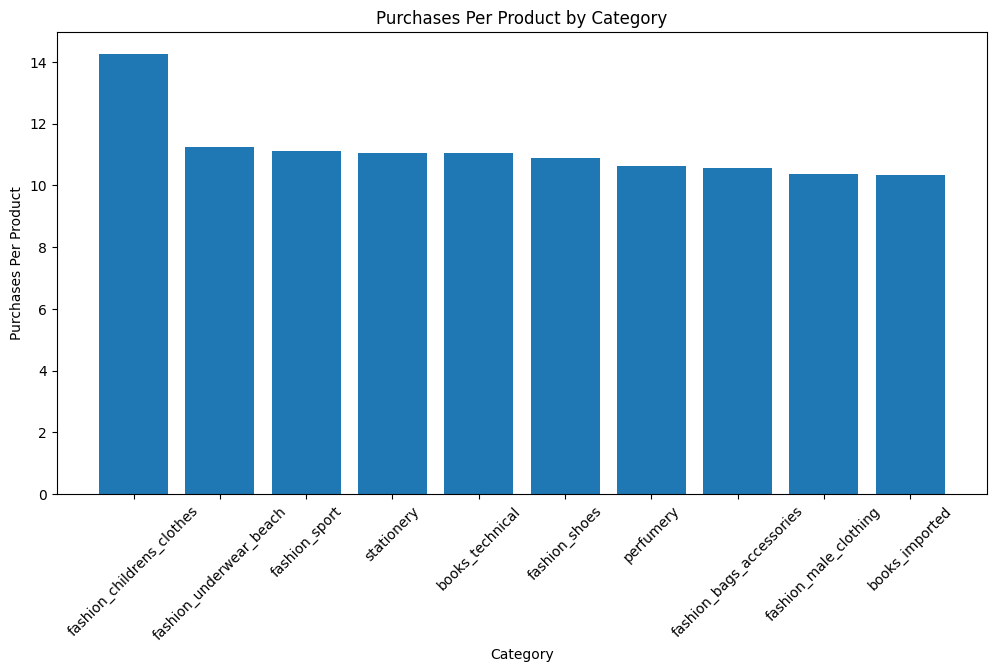

In [51]:
#Products vs Purchases

# MERGE BOTH TABLES

comparison = pd.merge(category_products,category_purchases,on='Category_name')


# PURCHASES PER PRODUCT

comparison['purchase_per_product'] = (comparison['total_purchases']/comparison['total_products'])


# SORT
comparison = comparison.sort_values(by='purchase_per_product',ascending=False)


# DISPLAY OUTPUT

print(comparison)

# VISUALIZATION

top10 = comparison.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10['Category_name'],top10['purchase_per_product'])
plt.title('Purchases Per Product by Category')
plt.xlabel('Category')
plt.ylabel('Purchases Per Product')
plt.xticks(rotation=45)
plt.show()

In [52]:
comparison.head(20)

,Category_name,total_products,total_purchases,purchase_per_product
67,fashion_childrens_clothes,4,57,14.250000
46,fashion_underwear_beach,47,528,11.234043
60,fashion_sport,17,189,11.117647
12,stationery,760,8403,11.056579
28,books_technical,111,1227,11.054054
24,fashion_shoes,162,1766,10.901235
9,perfumery,809,8589,10.616811
11,fashion_bags_accessories,770,8123,10.549351
31,fashion_male_clothing,88,912,10.363636
51,books_imported,28,289,10.321429


In [53]:
#CHECKING WHY SOME PRODUCTS HAVE HIGH RVENEUE BUT LESS PROFIT 
# CREATE PROFIT MARGIN
# =========================
df['profit_margin_%'] = (
    (df['profit'] / df['selling_price']) * 100
)

# =========================
# CATEGORY-WISE ANALYSIS
# =========================
category_analysis = (

    df.groupby('Category_name')

    .agg({

        'selling_price'   : 'sum',
        'profit'          : 'sum',
        'discount(%)'     : 'mean',
        'shipping_cost'   : 'mean',
        'profit_margin_%' : 'mean',
        'product_weight_g': 'mean'

    })

    .reset_index()

)

# =========================
# RENAME COLUMNS
# =========================
category_analysis.columns = [

    'Category_name',
    'total_revenue',
    'total_profit',
    'avg_discount_%',
    'avg_shipping_cost',
    'avg_profit_margin_%',
    'avg_product_weight_g'

]

# =========================
# SORT BY REVENUE
# =========================
category_analysis = category_analysis.sort_values(
    by='total_revenue',
    ascending=False
)

# =========================
# DISPLAY OUTPUT
# =========================
print(category_analysis)

                Category_name  total_revenue  total_profit  avg_discount_%  \
39            furniture_decor    123195220.0    27483200.0       22.014140   
7              bed_bath_table     88325900.0    17720310.0       13.920155   
65             sports_leisure     84123470.0    16640270.0       13.730843   
43              health_beauty     71313710.0    14218100.0       14.036105   
49                 housewares     69385500.0    13834760.0       14.148034   
..                        ...            ...           ...             ...   
35                    flowers       339290.0       60250.0       13.246753   
23        diapers_and_hygiene       223180.0       43990.0       15.231136   
29  fashion_childrens_clothes       102350.0       40020.0       11.062807   
11          cds_dvds_musicals        67700.0       12600.0       18.124000   
61      security_and_services        48480.0        9600.0       21.478333   

    avg_shipping_cost  avg_profit_margin_%  avg_product_weight_

In [54]:
category_analysis.head(20)

,Category_name,total_revenue,total_profit,avg_discount_%,avg_shipping_cost,avg_profit_margin_%,avg_product_weight_g
39,furniture_decor,123195220.0,27483200.0,22.014140,4889.298409,22.159566,3024.908638
7,bed_bath_table,88325900.0,17720310.0,13.920155,602.740651,19.934423,2518.727473
65,sports_leisure,84123470.0,16640270.0,13.730843,605.503301,19.806479,1962.277911
43,health_beauty,71313710.0,14218100.0,14.036105,616.805549,20.016162,1399.751496
49,housewares,69385500.0,13834760.0,14.148034,614.880660,19.788285,3154.781870
15,computers_accessories,64182960.0,7296690.0,20.086280,3367.857870,11.552158,835.719039
5,auto,48648540.0,8065620.0,14.586313,651.183158,16.486653,2706.604556
69,toys,41847470.0,8444510.0,13.721663,586.835248,20.028242,1780.086712
70,watches_gifts,38119370.0,7843070.0,13.972903,596.115709,20.561106,550.260110
68,telephony,32484070.0,6403130.0,14.261953,625.407013,19.678611,243.536654


# Why Some Products Have High Revenue but Low Profit
### 1. Heavy Discounting Reduces Margins
- High sales volume driven by discounts inflates revenue
- But every % discount directly cuts into profit
- Common in electronics, computers, and competitive categories

### 2. High Shipping & Logistics Costs
- Heavy or bulky items cost more to ship
- High return costs further reduce profitability
- Seen in furniture, office furniture, auto parts

### 3. High Cost of Goods (COGS)
- Expensive sourcing or imported components
- Leaves very little room for profit even with strong sales
- Typical in tech categories

### 4. Low-Margin Category Dynamics
- Highly competitive markets force lower pricing
- Customers compare prices aggressively
- Revenue grows, but profit per unit stays small

### 5. Operational Overheads
- Storage, handling, packaging, and return processing
- High for large or fragile items
- Eats into profit despite strong revenue

## Summary
High revenue ≠ high profit.  
Profitability depends on discounting, logistics, cost structure, and category competitiveness, not just sales volume.

In [55]:
# =========================
# SEGMENT COMPARISON
# =========================
segment_comparison = (

    df.groupby('customer_segment')

    .agg({

        'selling_price' : 'mean',
        'profit'        : 'mean',
        'discount(%)'   : 'mean',
        'order_id'      : 'count'

    })

    .reset_index()

)

# =========================
# RENAME COLUMNS
# =========================
segment_comparison.columns = [

    'Customer Segment',
    'Avg Price',
    'Avg Profit',
    'Discount %',
    'Order Count'

]

# =========================
# ROUND VALUES
# =========================
segment_comparison = segment_comparison.round({

    'Avg Price'  : 2,
    'Avg Profit' : 2,
    'Discount %' : 2

})

# =========================
# SORT VALUES
# =========================
segment_comparison = segment_comparison.sort_values(
    by='Avg Price',
    ascending=False
)

# =========================
# DISPLAY OUTPUT
# =========================
print(segment_comparison)

  Customer Segment  Avg Price  Avg Profit  Discount %  Order Count
1              New    6874.64     1411.60       13.57        91986
2        Returning    6706.36     1377.05       13.47        64708
0            Loyal    6647.91     1354.38       13.51        27090


In [56]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 183784 entries, 159250 to 36640
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       183784 non-null  object        
 1   customer_id                    183784 non-null  object        
 2   order_status                   183784 non-null  object        
 3   payment_type                   183784 non-null  object        
 4   order_purchase_timestamp       183784 non-null  datetime64[ns]
 5   order_approved_at              174466 non-null  object        
 6   order_delivered_shipping_date  174466 non-null  object        
 7   order_delivered_customer_date  168999 non-null  datetime64[ns]
 8   order_estimated_delivery_date  174466 non-null  datetime64[ns]
 9   customer_zip_code              183784 non-null  int64         
 10  gender                         183784 non-null  object        
 11  a

In [57]:
# =========================
# CATEGORIES IN EACH
# DISCOUNT BAND
# =========================
discount_categories = (

    df.groupby('discount_range')

    ['Category_name']

    .unique()

    .reset_index()

)

print(discount_categories)

  discount_range                                      Category_name
0           0-10  [fashion_shoes, telephony, housewares, bed_bat...
1          10-20  [sports_leisure, fashion_bags_accessories, bed...
2          20-30  [furniture_decor, housewares, bed_bath_table, ...
3          30-40  [sports_leisure, bed_bath_table, health_beauty...
4          40-50  [bed_bath_table, furniture_living_room, furnit...
5            50+  [home_confort, sports_leisure, furniture_decor...


In [58]:
discount_categories

,discount_range,Category_name
0,0-10,"[fashion_shoes, telephony, housewares, bed_bat..."
1,10-20,"[sports_leisure, fashion_bags_accessories, bed..."
2,20-30,"[furniture_decor, housewares, bed_bath_table, ..."
3,30-40,"[sports_leisure, bed_bath_table, health_beauty..."
4,40-50,"[bed_bath_table, furniture_living_room, furnit..."
5,50+,"[home_confort, sports_leisure, furniture_decor..."


In [59]:
avg_order = df.groupby(
    ['discount_range', 'Category_name']
)['selling_price'].mean().reset_index()

print(avg_order)

    discount_range               Category_name  selling_price
0             0-10  agro_industry_and_commerce    4160.289017
1             0-10            air_conditioning    4054.628099
2             0-10                         art    2778.048780
3             0-10       arts_and_craftmanship    3936.666667
4             0-10                       audio   10400.000000
..             ...                         ...            ...
421            50+                  stationery            NaN
422            50+      tablets_printing_image            NaN
423            50+                   telephony   17216.666667
424            50+                        toys   16232.000000
425            50+               watches_gifts   17688.000000

[426 rows x 3 columns]


In [60]:
avg_order

,discount_range,Category_name,selling_price
0,0-10,agro_industry_and_commerce,4160.289017
1,0-10,air_conditioning,4054.628099
2,0-10,art,2778.048780
3,0-10,arts_and_craftmanship,3936.666667
4,0-10,audio,10400.000000
...,...,...,...
421,50+,stationery,NaN
422,50+,tablets_printing_image,NaN
423,50+,telephony,17216.666667
424,50+,toys,16232.000000


In [61]:
# Categories in each discount range
# + Number of categories

discount_categories = df.groupby(
    'discount_range'
)['Category_name'].unique().reset_index()

# Count number of categories
discount_categories['no_of_categories'] = (
    discount_categories['Category_name']
    .apply(len)
)

print(discount_categories)

  discount_range                                      Category_name  \
0           0-10  [fashion_shoes, telephony, housewares, bed_bat...   
1          10-20  [sports_leisure, fashion_bags_accessories, bed...   
2          20-30  [furniture_decor, housewares, bed_bath_table, ...   
3          30-40  [sports_leisure, bed_bath_table, health_beauty...   
4          40-50  [bed_bath_table, furniture_living_room, furnit...   
5            50+  [home_confort, sports_leisure, furniture_decor...   

   no_of_categories  
0                69  
1                71  
2                70  
3                59  
4                54  
5                35  


In [62]:
# Filter only first purchases
df_first = df[df['purchase_number'] == 1]

# Group by Age Group + Category and count
age_cat_counts = (
    df_first.groupby(['age_group', 'Category_name'])
            .size()
            .reset_index(name='first_purchase_count')
)

# For each age group, pick the category with the highest count
top_category_per_age = (
    age_cat_counts.sort_values(['age_group', 'first_purchase_count'], ascending=[True, False])
                  .groupby('age_group')
                  .head(3)
)

top_category_per_age


,age_group,Category_name,first_purchase_count
5,18-25,bed_bath_table,427
55,18-25,sports_leisure,412
36,18-25,health_beauty,357
68,26-35,bed_bath_table,851
123,26-35,sports_leisure,794
103,26-35,health_beauty,711
136,36-45,bed_bath_table,1304
192,36-45,sports_leisure,1182
171,36-45,health_beauty,967
205,46-55,bed_bath_table,624


In [63]:
# Filter only first purchases
df_first = df[df['purchase_number'] == 1]

# Group by Region + Category and count
region_cat_counts = (
    df_first.groupby(['region', 'Category_name'])
            .size()
            .reset_index(name='first_purchase_count')
)

# For each region, pick the category with the highest count
top_category_per_region = (
    region_cat_counts.sort_values(['region', 'first_purchase_count'], ascending=[True, False])
                     .groupby('region')
                     .head(3)
)

top_category_per_region


,region,Category_name,first_purchase_count
6,Central,bed_bath_table,246
57,Central,sports_leisure,202
38,Central,health_beauty,195
69,East,bed_bath_table,706
124,East,sports_leisure,585
104,East,health_beauty,483
137,North,bed_bath_table,891
192,North,sports_leisure,880
171,North,health_beauty,757
250,Northeast,sports_leisure,176


In [64]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'payment_type',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_shipping_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_zip_code', 'gender',
       'age_group', 'customer_segment', 'order_item_id', 'quantity',
       'product_id', 'unit_price', 'discount(%)', 'shipping_cost',
       'Category_name', 'sub_category_name', 'product_weight_g', 'brand',
       'cost_price', 'selling_price', 'stock_availability', 'review_id',
       'review_score', 'review_date', 'geolocation_state', 'region',
       'discount_range', 'price_range', 'rating_range', 'purchase_number',
       'is_delayed', 'is_repeat', 'profit', 'shipping_range', 'cancel_flag',
       'repeat_purchase', 'prev_purchase_date', 'days_between_purchase',
       'repurchase_window', 'profit_margin_%'],
      dtype='object')

In [65]:
# Probability of Repeat Purchase

repeat_purchase_prob = df['is_repeat'].mean()

print("P(Repeat Purchase) =", round(repeat_purchase_prob,3))

P(Repeat Purchase) = 0.499


In [66]:
# Probability of Delayed Delivery

delay_prob = df['is_delayed'].mean()

print("P(Delayed Delivery) =", round(delay_prob,3))

P(Delayed Delivery) = 0.668


In [68]:
# Chi-Square Test – Region vs Customer Segment

from scipy.stats import chi2_contingency
import pandas as pd

contingency_table = pd.crosstab(
    df['region'],
    df['customer_segment']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("P-value:", p)

P-value: 0.00487727961287849


In [69]:
# Chi-Square Test – Discount Range vs Segment

contingency_table = pd.crosstab(
    df['discount_range'],
    df['customer_segment']
)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("P-value:", p)

P-value: 0.7389039274701192
